# SC Best Practices Pipeline Preprocessing
1. Quality Control
2. Normalization
3. Feature selection
4. Dimensionality reduction

https://www.sc-best-practices.org/

## Quality Control
https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html

In [34]:
import os

# Force ABI mode before rpy2 initializes
os.environ["RPY2_CFFI_MODE"] = "ABI"
os.environ["R_HOME"] = r"C:\Program Files\R\R-4.4.1"

In [35]:
import lamindb as ln
import numpy as np

import scanpy as sc
import seaborn as sns
#from rpy2.robjects import numpy2ri
#from rpy2.robjects.conversion import localconverter
from scipy.sparse import csc_matrix
from scipy.stats import median_abs_deviation

# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

#assert ln.setup.settings.instance.slug == "theislab/sc-best-practices"
# ln.track()


from matplotlib import pyplot as plt

In [ ]:
H5AD_FILENAME = "mbQtuiVK5nGT6IZ10002"
N_MADS = 5

In [88]:
# Load the .h5ad file
adata = sc.read_h5ad(H5AD_FILENAME + ".h5ad")
adata

c:\Users\eliac\OneDrive\Documenti\scRNA-Seq 2026\sc-best-prac-prep.venv\lib\site-packages\anndata\_core\anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [38]:
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 16934 × 36601
    var: 'gene_ids', 'feature_types', 'genome', 'interval'

In [39]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(r"^HB[ABDEGMQZ]\d*(?!\w)")

In [40]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 16934 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

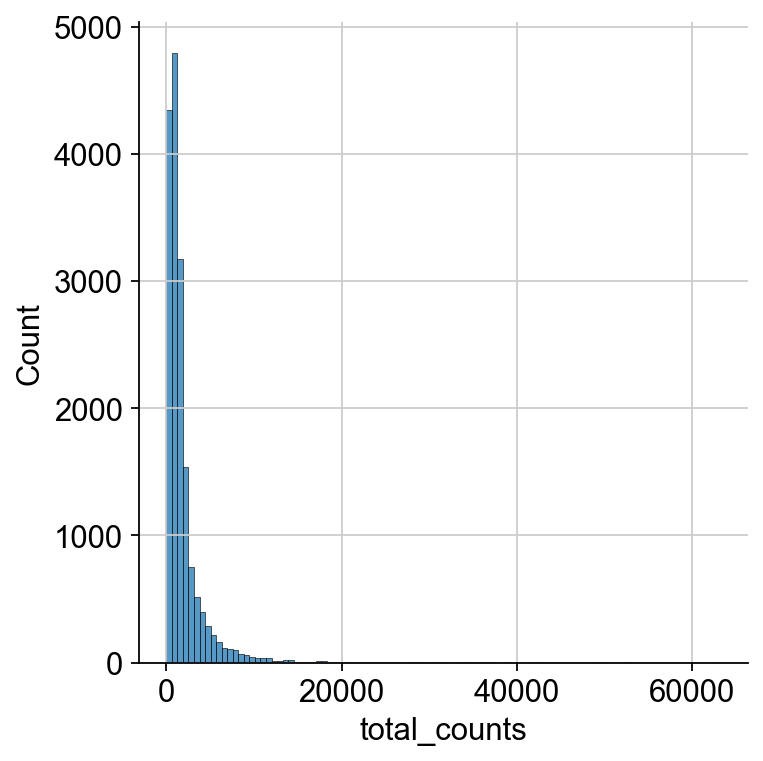

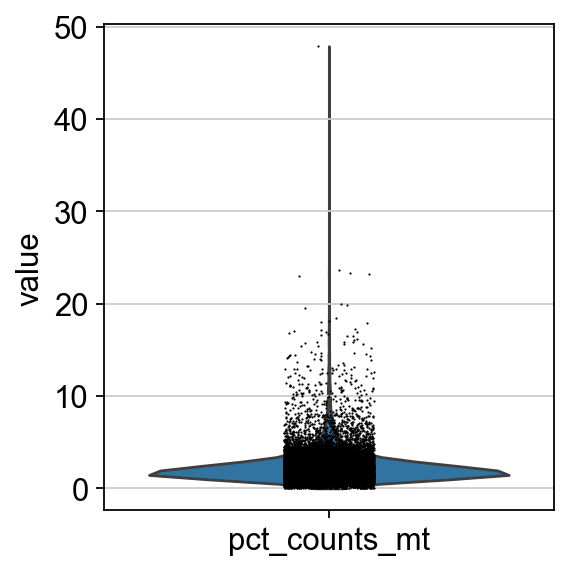

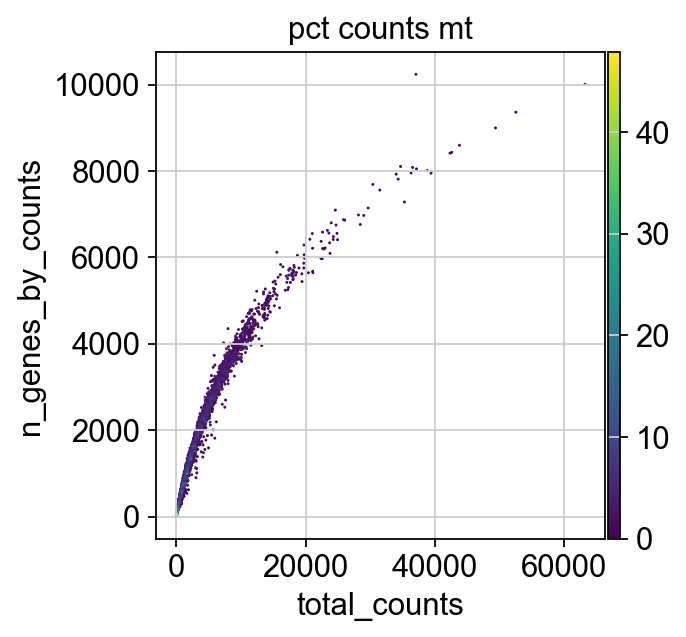

In [41]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [42]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [43]:
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", N_MADS)
    | is_outlier(adata, "log1p_n_genes_by_counts", N_MADS)
    | is_outlier(adata, "pct_counts_in_top_20_genes", N_MADS)
)
adata.obs.outlier.value_counts()

outlier
False    16065
True       869
Name: count, dtype: int64

In [44]:
adata.obs["mt_outlier"] = is_outlier(adata, "pct_counts_mt", 3) | (
    adata.obs["pct_counts_mt"] > 8
)
adata.obs.mt_outlier.value_counts()

mt_outlier
False    15240
True      1694
Name: count, dtype: int64

In [45]:
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 16934
Number of cells after filtering of low quality cells: 14814


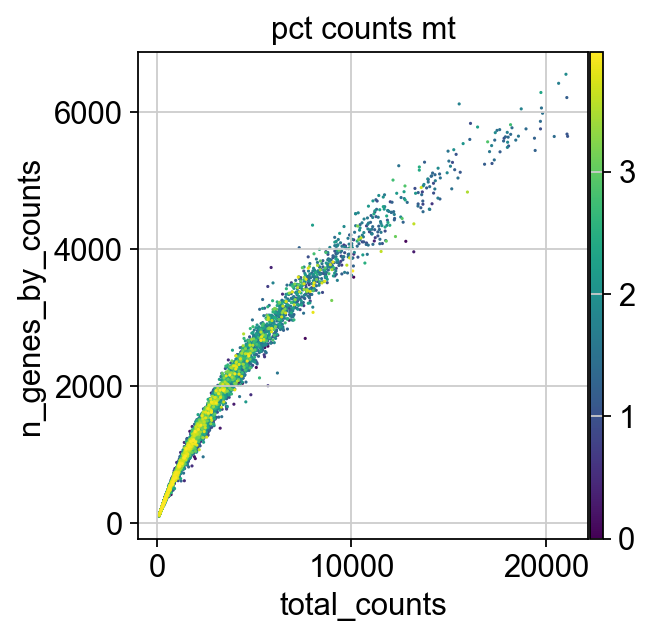

In [46]:
p1 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

### Skip:
- Correction of ambient RNA (needs clustering)
- Doublet Detection

In [ ]:
### CUSTOM CODE
# Save data to .h5ad file

# Save raw counts before normalization so we can use them later for HVG selection
adata.layers["counts"] = adata.X.copy()

adata.write(H5AD_FILENAME + "_qc.h5ad")



## Normalization
These counts represent a molecule’s capture, reverse transcription and sequencing in the scRNA-seq experiment. Each of these steps adds a degree of variability to the measured count depth for identical cells, so the difference in gene expression between cells in the count data might simply be due to sampling effects.

This means that the dataset and therefore the count matrix still contains widely varying variance terms. Analyzing the dataset is often challenging as many statistical methods assume data with uniform variance structure.

Normalization aims to adjust the raw counts in the dataset for variable sampling effects by scaling the observable variance to a specified range.


In [ ]:
### CUSTOM CODE
# Load the filtered .h5ad file
adata_qc = sc.read_h5ad(H5AD_FILENAME + "_qc.h5ad")
adata = adata_qc.copy()
adata

AnnData object with n_obs × n_vars = 14814 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts'

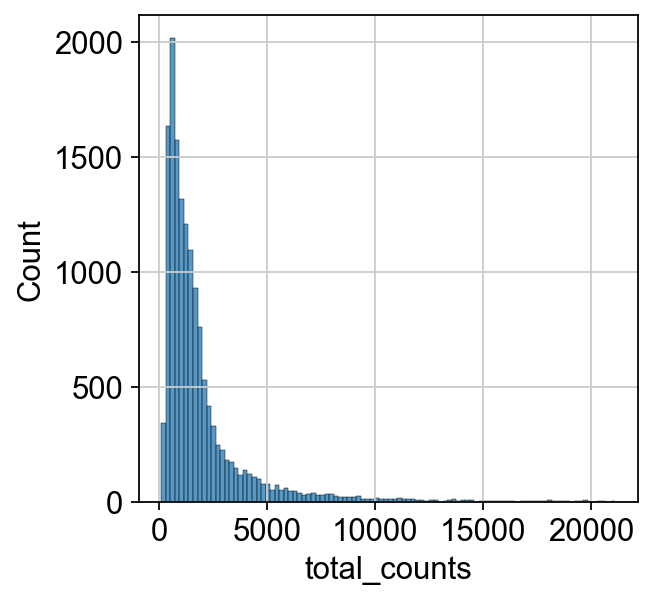

In [49]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

### Shifted logarithm normalization techique (1 out of 3)

In [50]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

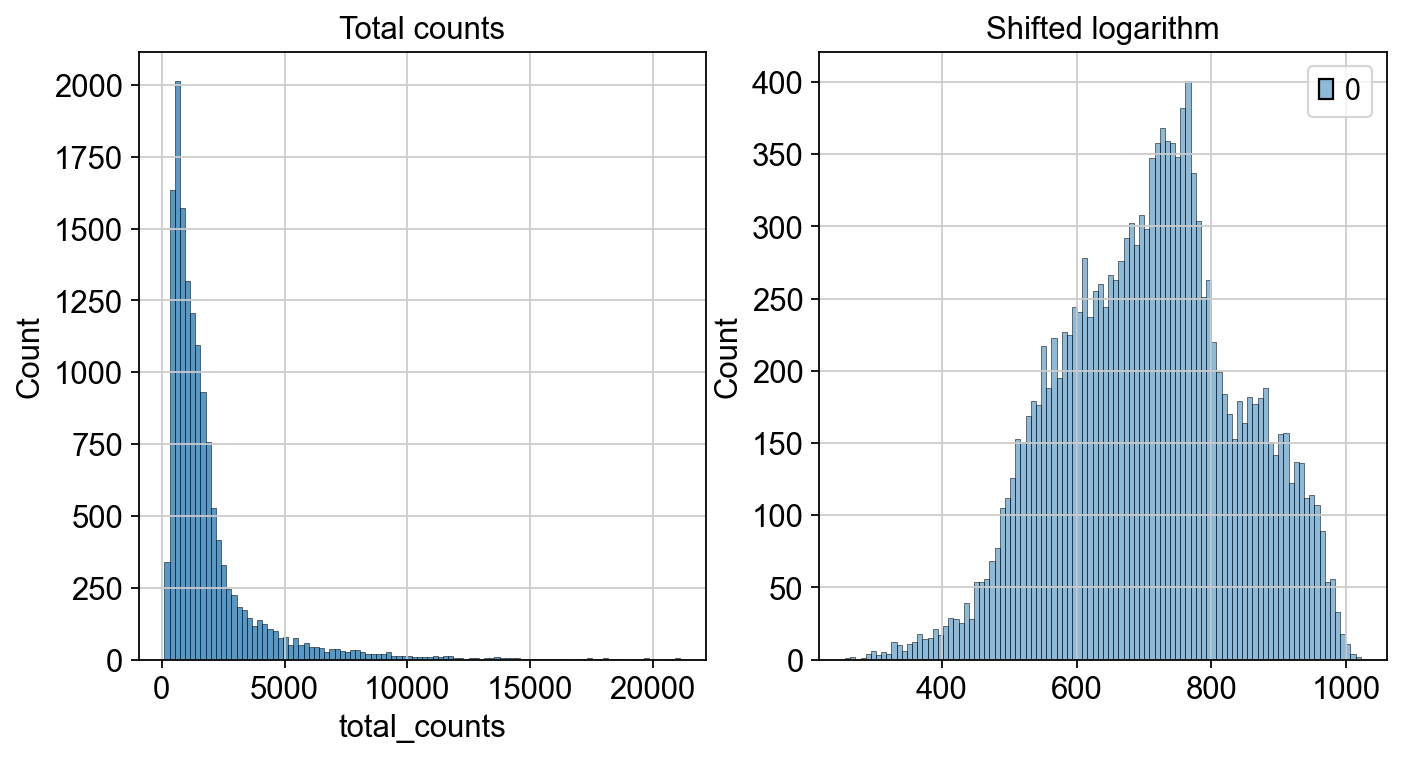

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Skip the other 2 normalization methods:
- Scran’s pooling-based size factor estimation method (needs previous clustering) (**used for batch correction**)
- Analytic Pearson residuals

In [ ]:
### CUSTOM CODE
# Save data to .h5ad file
adata.write(H5AD_FILENAME + "_qc_norm.h5ad")

## Feature selection (highly variable genes)
We now have a normalized data representation that still preserves biological heterogeneity but with reduced technical sampling effects in gene expression.
ScRNA-seq datasets usually contain up to 30,000 genes (depending on the organism) and so far we only removed genes that are not detected in at least 20 cells.
However, many of the remaining genes are not informative and contain mostly zero counts.

Therefore, a standard preprocessing pipeline involves the step of feature selection which aims to exclude uninformative genes which might not represent meaningful biological variation across samples.

In [ ]:
### CUSTOM CODE
# Load the filtered and normalized .h5ad file
adata_qc_norm = sc.read_h5ad(H5AD_FILENAME + "_qc_norm.h5ad")
adata = adata_qc_norm.copy()
adata

AnnData object with n_obs × n_vars = 14814 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'counts', 'log1p_norm'

In [54]:
### CUSTOM CODE (To avoid to use R code)

# (Do not use log-normalized data, but adata.X is not normalized, only the layer log1p_norm)

# 1. Run feature selection using the raw counts layer
sc.experimental.pp.highly_variable_genes(
    adata,
    flavor="pearson_residuals",
    n_top_genes=4000,
    layer="counts", # Change this to the exact name of your raw counts layer
    subset=False    # Keep False so you don't delete the other genes yet
)

# 2. Check the output
# This adds 'highly_variable' (boolean) and 'residual_variances' to adata.var
print(adata.var[["highly_variable", "residual_variances"]].head())

             highly_variable  residual_variances
MIR1302-2HG            False            0.322530
FAM138A                False            0.000000
OR4F5                  False            0.000000
AL627309.1             False            0.804407
AL627309.3             False            0.000000


In [55]:
adata

AnnData object with n_obs × n_vars = 14814 × 36601
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_ids', 'feature_types', 'genome', 'interval', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'hvg'
    layers: 'counts', 'log1p_norm'

In [56]:
adata.var.highly_variable.value_counts()

highly_variable
False    32601
True      4000
Name: count, dtype: int64

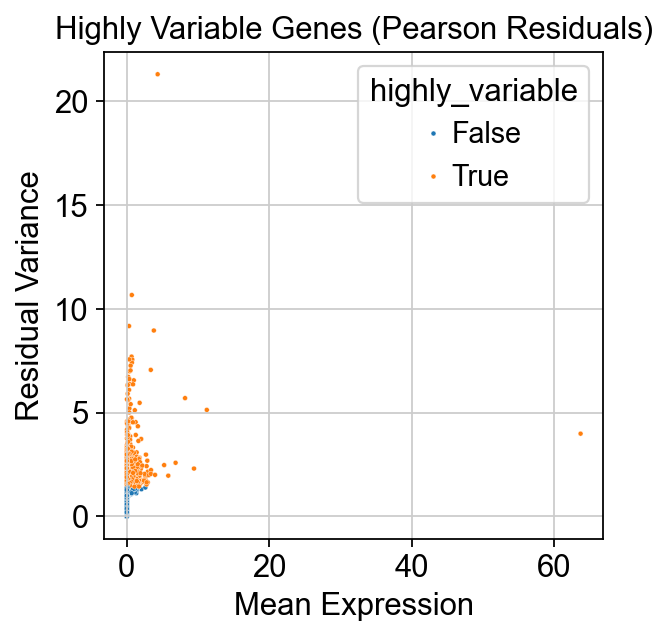

In [57]:
ax = sns.scatterplot(
    data=adata.var, 
    x="means", 
    y="residual_variances", 
    hue="highly_variable", 
    s=5
)

# Optional: Add a title and labels for clarity
ax.set_title("Highly Variable Genes (Pearson Residuals)")
ax.set_xlabel("Mean Expression")
ax.set_ylabel("Residual Variance")

plt.show()


In [ ]:
### CUSTOM CODE
# Save data to .h5ad file

adata.write(H5AD_FILENAME + "_qc_norm_hvg.h5ad")

## Dimensionality Reduction
Not all genes are informative and therefore not all genes are essential for tasks such as clustering. We already aimed to reduce the dimensionality of the data with feature selection.

In [76]:
if 'adata' in locals():
    del adata
if 'adata_qc' in locals():
    del adata_qc
if 'adata_qc_norm' in locals():
    del adata_qc_norm
if 'adata_qc_norm_hvg' in locals():
    del adata_qc_norm_hvg

In [80]:
# Suppress verbose logging from Scanpy
sc.settings.verbosity = 0

# Set figure parameters for clean, minimal plots
sc.settings.set_figure_params(dpi=80, facecolor="white", frameon=False)

In [ ]:
### CUSTOM CODE
# Load the filtered, normalized, and HVG-selected .h5ad file
adata_qc_norm_hvg = sc.read_h5ad(H5AD_FILENAME + "_qc_norm_hvg.h5ad")
adata = adata_qc_norm_hvg.copy()

In [ ]:
# Make the log-normalized data the primary representation in .X
adata.X = adata.layers["log1p_norm"].copy()

### CUSTOM CODE
# Scale the data to unit variance and zero mean (clipping extreme outliers at 10)
sc.pp.scale(adata, max_value=10)

# Run PCA, instructing Scanpy to only look at the 4,000 highly variable genes
### COMPUTATIONAL HEAVY
sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=True)

C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
c:\Users\eliac\OneDrive\Documenti\scRNA-Seq 2026\sc-best-prac-prep.venv\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


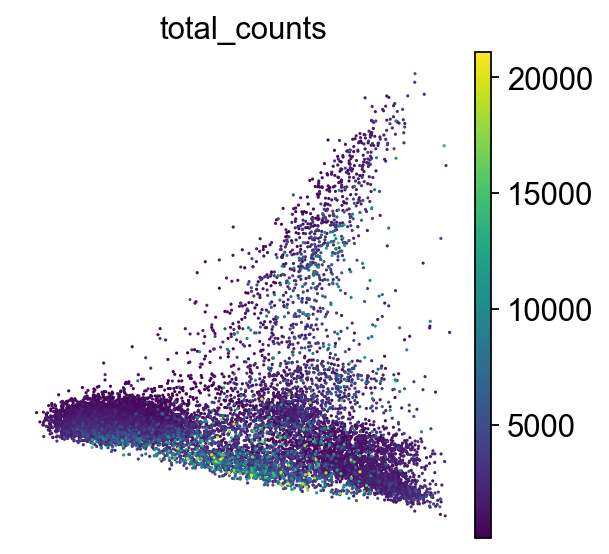

In [73]:
sc.pl.pca_scatter(adata, color="total_counts")

In [ ]:
### COMPUTATIONAL HEAVY
sc.pp.neighbors(adata)
sc.tl.umap(adata)

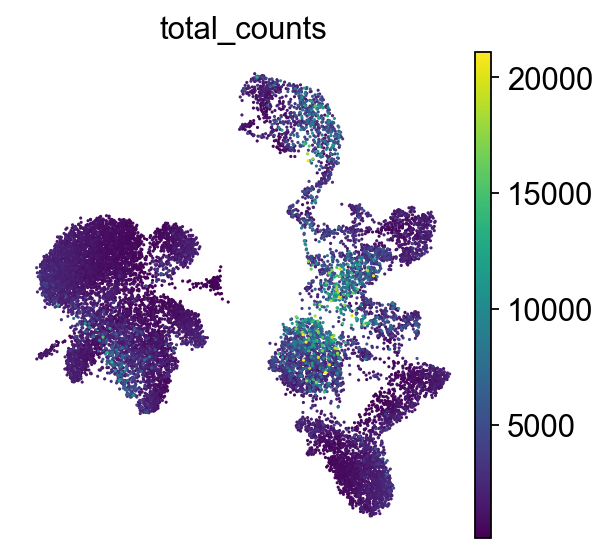

In [84]:
sc.pl.umap(adata, color="total_counts")

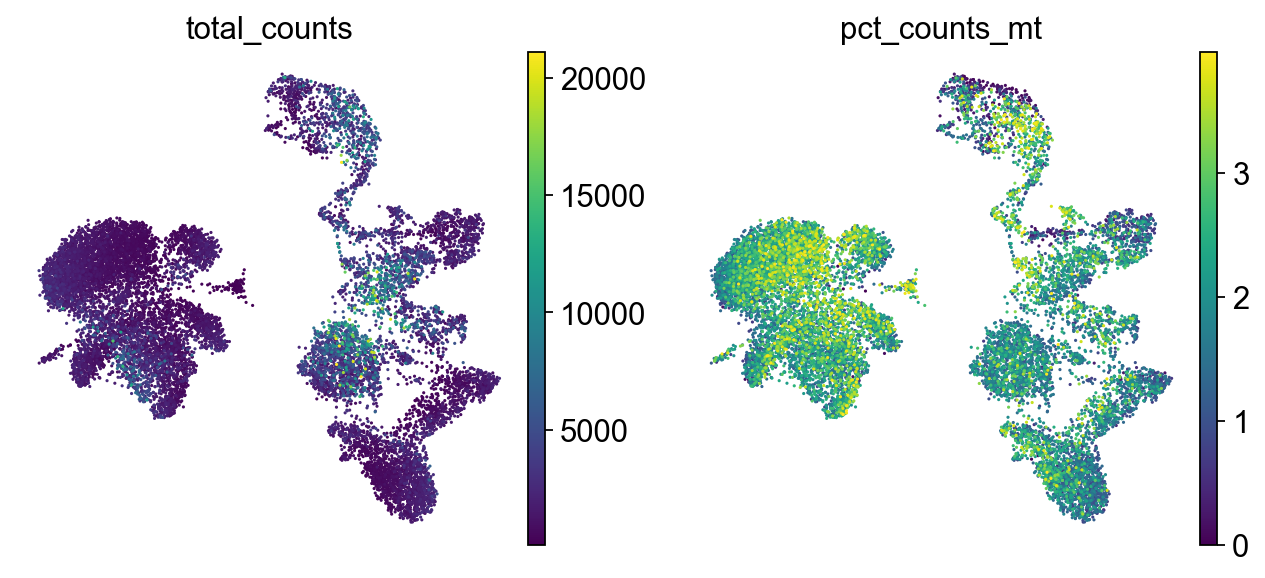

In [85]:
sc.pl.umap(
    adata,
    color=["total_counts", "pct_counts_mt"],
)

In [ ]:
### CUSTOM CODE
# Save data to .h5ad file

adata.write(H5AD_FILENAME + "_preprocessed.h5ad")

Done